In [1]:
from pathlib import Path
import gzip
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [2]:
sns.set_theme(context="paper", style="ticks")

In [3]:
root = Path("../results/exp_2")
all_jsons = list(root.rglob("*.json.gz"))
graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path('../data/anon_14_day_instances/2020-08-27.yaml'))

In [4]:
data = []
for file in all_jsons:
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        aggregate_payload = json.load(f)


    for payload in aggregate_payload["runs"]:
        vanilla = payload["summary_vanilla"]
        structured = payload["summary_structured"]
        dominance = payload["summary_dominance"]
        avg_epsilon = np.mean(list(payload["sampled_inputs"]["epsilons"].values()))
        fruit_value = (np.sum(list(payload["sampled_inputs"]["quantities"].values())) * instance.fruit_price_per_ton / instance.lc_to_usd),
        intermediaries = vanilla["instance_snapshot"]["intermediaries"]

        vanilla_profit = vanilla["platform_solve_result"]["max_intermediary_welfare_result"]["platform_profit"] / instance.lc_to_usd
        structured_profit = structured["platform_solve_result"]["max_intermediary_welfare_result"]["platform_profit"] / instance.lc_to_usd
        dominance_profit = dominance["platform_solve_result"]["max_intermediary_welfare_result"]["platform_profit"] / instance.lc_to_usd
        suboptimal_profit = vanilla["forced_lower_bound"] / instance.lc_to_usd

        time_vanilla = vanilla["total_time"]
        time_structured = structured["total_time"]
        time_dominance = dominance["total_time"]
        time_suboptimal = vanilla["timestamps"][0]

        max_farmer_welfare_pct = vanilla["platform_solve_result"]["max_farmer_welfare_result"]["farmer_welfare"] / instance.lc_to_usd / fruit_value[0]
        min_farmer_welfare_pct = vanilla["platform_solve_result"]["max_intermediary_welfare_result"]["farmer_welfare"] / instance.lc_to_usd / fruit_value[0]
        max_intermediary_welfare_pct = vanilla["platform_solve_result"]["max_intermediary_welfare_result"]["intermediary_welfare"] / instance.lc_to_usd / fruit_value[0]
        min_intermediary_welfare_pct = vanilla["platform_solve_result"]["max_farmer_welfare_result"]["intermediary_welfare"] / instance.lc_to_usd / fruit_value[0]

        profit_pct = vanilla_profit / fruit_value[0]
        instance_id = vanilla["instance_snapshot"]["instance_id"]

        matching_cost = vanilla["platform_solve_result"]["max_farmer_welfare_result"]["expected_intermediary_cost"] / instance.lc_to_usd / fruit_value[0]

        data.append({
            "vanilla_profit": vanilla_profit,
            "structured_profit": structured_profit,
            "domination_profit": dominance_profit,
            "suboptimal_profit": suboptimal_profit,
            "time_vanilla": time_vanilla,
            "time_structured": time_structured,
            "time_domination": time_dominance,
            "time_suboptimal": time_suboptimal,
            "avg_epsilon": avg_epsilon,
            'fruit_value': fruit_value[0],
            'profit_percentage': profit_pct,
            "instance": instance_id,
            'max_welfare_farmers': max_farmer_welfare_pct,
            'min_welfare_farmers': min_farmer_welfare_pct,
            'max_welfare_intermediaries': max_intermediary_welfare_pct,
            'min_welfare_intermediaries': min_intermediary_welfare_pct,
            'matching_cost': matching_cost,

        })  

df_gaps = pd.DataFrame(data)

df_gaps["diff_suboptimal"] = (df_gaps["vanilla_profit"] - df_gaps["suboptimal_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_structured"] = (df_gaps["vanilla_profit"] - df_gaps["structured_profit"])/ df_gaps["fruit_value"]
df_gaps["diff_domination"] = (df_gaps["vanilla_profit"] - df_gaps["domination_profit"])/ df_gaps["fruit_value"]

df_gaps["suboptimal_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_suboptimal"]
df_gaps["structured_speedup"] = df_gaps["time_vanilla"] / df_gaps["time_structured"]

df_gaps["vanilla_profit_by_fruit_value"] = df_gaps["vanilla_profit"] / df_gaps["fruit_value"]
df_gaps["structured_profit_by_fruit_value"] = df_gaps["structured_profit"] / df_gaps["fruit_value"]
df_gaps["domination_profit_by_fruit_value"] = df_gaps["domination_profit"] / df_gaps["fruit_value"]
df_gaps["suboptimal_profit_by_fruit_value"] = df_gaps["suboptimal_profit"] / df_gaps["fruit_value"]


In [5]:
actual_costs_platform = {
    0: 0.0775829869015126,
    1: 0.07768902868743288,
    2: 0.07792714074761442,
    3: 0.07779050019770295,
    4: 0.07780432119364723,
    5: 0.07780432119364725,
    6: 0.07758298690151258,
    7: 0.07758298690151257,
    8: 0.07758298690151258,
    9: 0.0775829869015126,
 }

actual_costs_improvement = {i: actual_costs_platform[i] - actual_costs_platform[0] for i in range(1, 10)}

actual_perc_platform = {
    0: 0.09959740695143612,
    1: 0.044517655245960054,
    2: 0.022845478696154217,
    3: 0.011845342163052535,
    4: 0.005042216382378989,
    5: 0.0009595428605521555,
    6: -0.002270061056467741,
    7: -0.004516052387438745,
    8: -0.005835568402234102,
    9: -0.007022154488203626
 }

actual_max_int = {
    0: 0.32758953661755996,
    1: 0.04175691614041955,
    2: 0.02060091126517644,
    3: 0.013039289559810586,
    4: 0.009350912870058112,
    5: 0.007924168304404811,
    6: 0.00772484422378011,
    7: 0.007443614889069343,
    8: 0.0063391957909994575,
    9: 0.005711990106601736
 }

actual_min_int = {
    0: 0.0,
    1: 0.01478574070810623,
    2: 0.007534357335050608,
    3: 0.007899933576455203,
    4: 0.005905858766726449,
    5: 0.006235383720283765,
    6: 0.0058198497457951585,
    7: 0.0073826381391337735,
    8: 0.006322061118747919,
    9: 0.00571137535532129
 }

actual_min_farmer = {
    0: 0.4952300812484759,
    1: 0.8360364116451723,
    2: 0.8786264810100395,
    3: 0.8973248797984186,
    4: 0.9078025612729003,
    5: 0.9133119793603803,
    6: 0.9169622416501595,
    7: 0.9194894623158415,
    8: 0.9219133974287067,
    9: 0.9237271891990739
 }

actual_max_farmer = {
    0: 0.8228196178660359,
    1: 0.8630075870774853,
    2: 0.8916930349401653,
    3: 0.9024642357817737,
    4: 0.911247615376232,
    5: 0.9150007639445015,
    6: 0.9188672361281446,
    7: 0.9195504390657769,
    8: 0.9219305321009583,
    9: 0.9237278039503545
 }



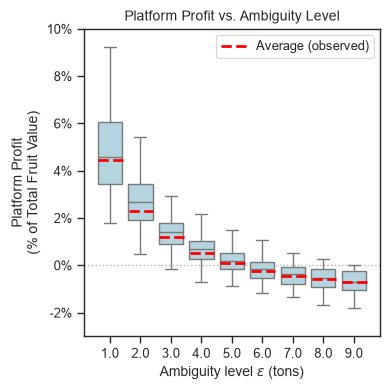

In [6]:
df_gaps = df_gaps.query("avg_epsilon >= 1.0")

plt.figure(figsize=(4, 4))

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})


ax = sns.boxplot(
    data=df_gaps, 
    x="avg_epsilon", 
    y="profit_percentage", 
    zorder=1, 
    showfliers=False,
    color="lightblue"
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)


for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )


ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level")

handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(handles[:1], labels[:1], loc="upper right")
plt.ylim(-0.03, 0.1)
plt.tight_layout()
plt.savefig("../figures/exp_2/platform_profit.png", bbox_inches='tight', dpi=300)
plt.show()

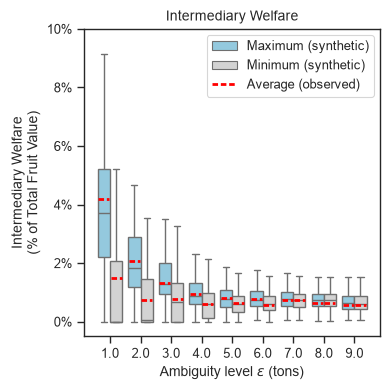

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (synthetic)": "skyblue", 
    "Minimum (synthetic)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_intermediaries', 'min_welfare_intermediaries'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_intermediaries': 'Maximum (synthetic)', 
    'min_welfare_intermediaries': 'Minimum (synthetic)'
})

# Create boxplot
plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Intermediary Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (synthetic)"], unique["Minimum (synthetic)"], unique["Average (observed)"]],
    ["Maximum (synthetic)", "Minimum (synthetic)", "Average (observed)"],
    title="", loc="upper right"
)
plt.ylim(-0.005, 0.1)
plt.tight_layout()
plt.savefig("../figures/exp_2/intermediary_welfare.png", bbox_inches='tight', dpi=300)
plt.show()

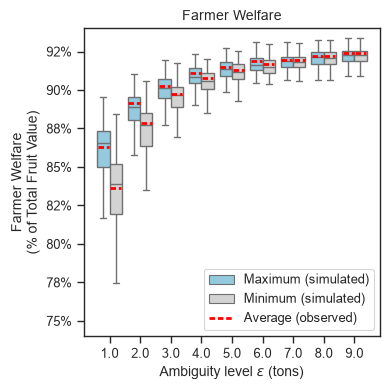

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually to ensure consistency
palette = {
    "Maximum (simulated)": "skyblue", 
    "Minimum (simulated)": "lightgray"
}

# Melt the dataframe
df_melted = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['max_welfare_farmers', 'min_welfare_farmers'], 
    var_name='Welfare Type', 
    value_name='Welfare'
)

# Improve category names for legend
df_melted['Welfare Type'] = df_melted['Welfare Type'].map({
    'max_welfare_farmers': 'Maximum (simulated)', 
    'min_welfare_farmers': 'Minimum (simulated)'
})

# Create boxplot
plt.figure(figsize=(4, 4))  # Adjusted figsize
ax = sns.boxplot(
    data=df_melted, 
    x="avg_epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette=palette, 
    showfliers=False
)

# Overlay actual data lines with red dashed lines for averages
for i, category in enumerate(sorted(df_gaps["avg_epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

# Labeling
plt.ylabel("Farmer Welfare\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare")

# Legend cleanup
handles, labels = ax.get_legend_handles_labels()
# Deduplicate legend and ensure all three entries are present
unique = dict(zip(labels, handles))
plt.legend(
    [unique["Maximum (simulated)"], unique["Minimum (simulated)"], unique["Average (observed)"]],
    ["Maximum (simulated)", "Minimum (simulated)", "Average (observed)"],
    title="", loc="lower right"
)
plt.ylim(0.74, 0.94)
plt.tight_layout()
plt.savefig("../figures/exp_2/farmer_welfare.png", bbox_inches='tight', dpi=300)
plt.show()

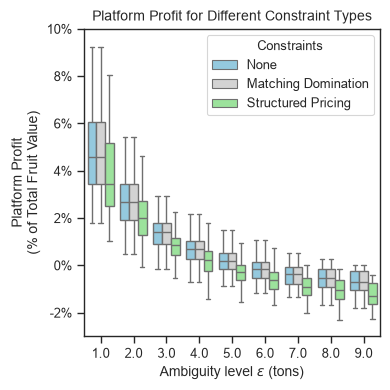

In [9]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

import matplotlib.pyplot as plt

# Melt the dataframe for easier plotting
profit_data = df_gaps.melt(
    id_vars='avg_epsilon', 
    value_vars=['vanilla_profit_by_fruit_value', 'domination_profit_by_fruit_value', 'structured_profit_by_fruit_value'], 
    var_name='Constraints', 
    value_name='Profit'
)

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# Set color palette manually for consistency
palette = {
    "None": "skyblue", 
    "Matching Domination": "lightgray", 
    "Structured Pricing": "lightgreen"
}

# Improve category names for legend
profit_data['Constraints'] = profit_data['Constraints'].map({
    'vanilla_profit_by_fruit_value': 'None', 
    'domination_profit_by_fruit_value': 'Matching Domination', 
    'structured_profit_by_fruit_value': 'Structured Pricing'
})

# Create the boxplot
plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=profit_data, 
    x="avg_epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette=palette, 
    showfliers=False
)

# Format y-axis
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

# Labeling
plt.ylabel("Platform Profit\n(% of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit for Different Constraint Types")
# Format y-axis as percentages
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

plt.ylim(-0.03, 0.1)

# Adjust legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraints", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/exp_2/profit_by_constraint.png", bbox_inches='tight', dpi=300)
plt.show()